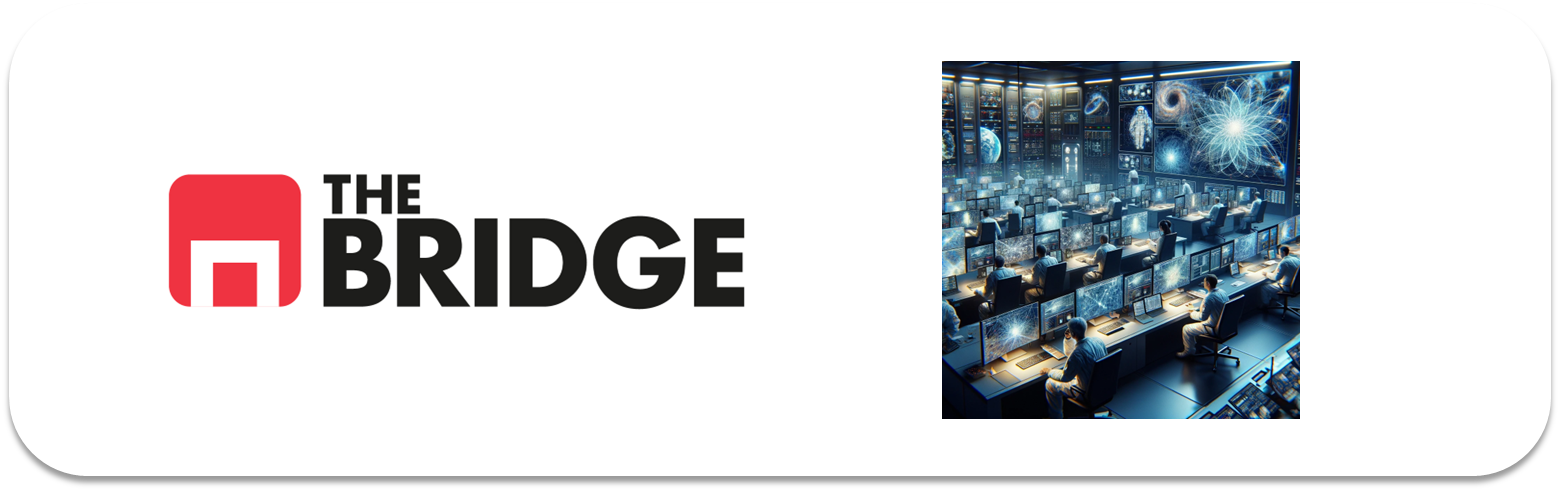

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [33]:
import os

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore")

### Ejercicio 1: Preparación de los datos

Reutilizamos la carga de datos, la función de visualización y el miniEDA del ejercicio de clasificación de paisajes de la Unidad 1 (dataset [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification) de Kaggle: `seg_train`/`seg_test`, 6 clases de paisajes).

Recorremos las carpetas de `seg_train` y `seg_test` (una por clase) leyendo cada imagen y redimensionándola. A diferencia de la Unidad 1 usamos una resolución algo mayor (96x96) porque los modelos preentrenados de Keras exigen como mínimo 32x32 y funcionan mejor con más resolución.

In [34]:
ROOT_PATH = "./dataset/"
TRAIN_PATH = ROOT_PATH + "seg_train/seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/seg_test/"


def read_data(directorio, reshape_dim=(96, 96)):
    # Usamos os.walk (en vez de asumir un unico nivel de subcarpetas) porque el zip de
    # Kaggle a veces se descomprime con una carpeta anidada extra (seg_train/seg_train/<clase>/...)
    X = []
    y = []
    for root, dirs, files in os.walk(directorio):
        for file in files:
            image = cv2.imread(os.path.join(root, file))
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, reshape_dim)

            X.append(image)
            y.append(os.path.basename(root))

            if len(X) % 1000 == 0:
                print(f"  {len(X)} imagenes leidas de {directorio}...")

    return np.array(X), np.array(y)

In [35]:
# Diagnostico rapido (solo cuenta ficheros, no los abre) para comprobar la estructura
# de carpetas y el volumen de datos antes de lanzar la carga completa con read_data
for path in [TRAIN_PATH, TEST_PATH]:
    n_files = sum(len(files) for _, _, files in os.walk(path))
    print(path, "->", n_files, "ficheros en total")
    for root, dirs, files in os.walk(path):
        if files:
            print("   ", root, ":", len(files), "ficheros")

./dataset/seg_train/seg_train/ -> 14034 ficheros en total
    ./dataset/seg_train/seg_train/buildings : 2191 ficheros
    ./dataset/seg_train/seg_train/forest : 2271 ficheros
    ./dataset/seg_train/seg_train/glacier : 2404 ficheros
    ./dataset/seg_train/seg_train/mountain : 2512 ficheros
    ./dataset/seg_train/seg_train/sea : 2274 ficheros
    ./dataset/seg_train/seg_train/street : 2382 ficheros
./dataset/seg_test/seg_test/ -> 3000 ficheros en total
    ./dataset/seg_test/seg_test/buildings : 437 ficheros
    ./dataset/seg_test/seg_test/forest : 474 ficheros
    ./dataset/seg_test/seg_test/glacier : 553 ficheros
    ./dataset/seg_test/seg_test/mountain : 525 ficheros
    ./dataset/seg_test/seg_test/sea : 510 ficheros
    ./dataset/seg_test/seg_test/street : 501 ficheros


In [36]:
IMG_SIZE = (96, 96)

X_train_raw, y_train_raw = read_data(TRAIN_PATH, IMG_SIZE)
X_test_raw, y_test_raw = read_data(TEST_PATH, IMG_SIZE)

print("Train:", X_train_raw.shape, y_train_raw.shape)
print("Test:", X_test_raw.shape, y_test_raw.shape)

  1000 imagenes leidas de ./dataset/seg_train/seg_train/...
  2000 imagenes leidas de ./dataset/seg_train/seg_train/...
  3000 imagenes leidas de ./dataset/seg_train/seg_train/...
  4000 imagenes leidas de ./dataset/seg_train/seg_train/...
  5000 imagenes leidas de ./dataset/seg_train/seg_train/...
  6000 imagenes leidas de ./dataset/seg_train/seg_train/...
  7000 imagenes leidas de ./dataset/seg_train/seg_train/...
  8000 imagenes leidas de ./dataset/seg_train/seg_train/...
  9000 imagenes leidas de ./dataset/seg_train/seg_train/...
  10000 imagenes leidas de ./dataset/seg_train/seg_train/...
  11000 imagenes leidas de ./dataset/seg_train/seg_train/...
  12000 imagenes leidas de ./dataset/seg_train/seg_train/...
  13000 imagenes leidas de ./dataset/seg_train/seg_train/...
  14000 imagenes leidas de ./dataset/seg_train/seg_train/...
  1000 imagenes leidas de ./dataset/seg_test/seg_test/...
  2000 imagenes leidas de ./dataset/seg_test/seg_test/...
  3000 imagenes leidas de ./dataset/seg

Función de visualización en batch, reutilizada de la Unidad 1, para revisar que la carga y el redimensionado se han hecho bien:

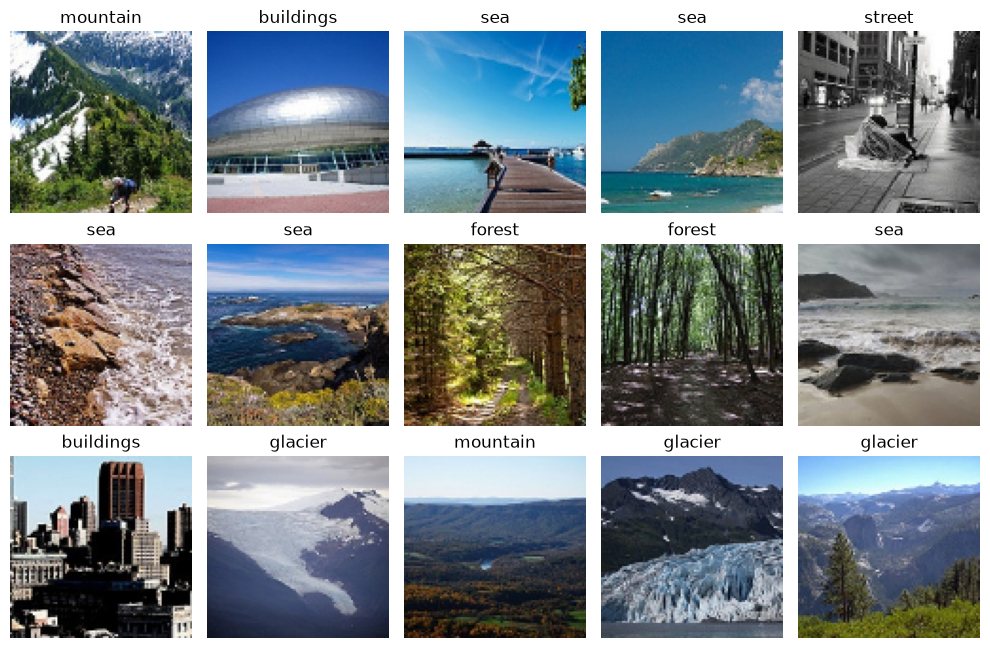

In [37]:
def show_images_batch(images, labels=None, n=15, n_cols=5):
    n_rows = (n - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))
    idx = np.random.choice(len(images), size=n, replace=False)
    for i, index in enumerate(idx):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(images[index])
        if labels is not None:
            plt.title(labels[index])
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_images_batch(X_train_raw, y_train_raw, n=15)

**MiniEDA**: balance de clases y rango de valores de los píxeles antes de normalizar.

In [38]:
targets = pd.Series(y_train_raw)
print(targets.value_counts(normalize=True))

print("Rango de píxeles (train):", X_train_raw.min(), "-", X_train_raw.max())
print("Dtype:", X_train_raw.dtype)

mountain     0.178994
glacier      0.171298
street       0.169731
sea          0.162035
forest       0.161821
buildings    0.156121
Name: proportion, dtype: float64
Rango de píxeles (train): 0 - 255
Dtype: uint8


Las clases están razonablemente equilibradas. Normalizamos (escalado por 255), codificamos la clase a un valor numérico y barajamos el train (las imágenes están cargadas ordenadas por carpeta/clase).

In [39]:
class_names = sorted(pd.Series(y_train_raw).unique())
label_map = {clase: indice for indice, clase in enumerate(class_names)}

X_train = X_train_raw.astype("float32") / 255.0
X_test = X_test_raw.astype("float32") / 255.0

y_train = np.array([label_map[label] for label in y_train_raw])
y_test = np.array([label_map[label] for label in y_test_raw])

X_train, y_train = shuffle(X_train, y_train, random_state=42)

print(class_names)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
(14034, 96, 96, 3) (14034,)
(3000, 96, 96, 3) (3000,)


### Ejercicio 2: Elección del modelo preentrenado

Escogemos **MobileNetV2** (https://keras.io/api/applications/mobilenet/), la opción recomendada en el enunciado por ser mucho más ligera que VGG-19 o InceptionV3, lo que permite entrenar en un portátil sin GPU dedicada en tiempos razonables.

In [40]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2

INPUT_SHAPE = (IMG_SIZE[0], IMG_SIZE[1], 3)

### Ejercicio 3: Transfer Learning

Cargamos MobileNetV2 sin su cabeza clasificadora (`include_top=False`) con los pesos de imagenet, y **congelamos** todas sus capas para no tocar los pesos ya entrenados. Encima montamos una cabeza propia de 2 capas densas ocultas + 1 de salida, tal y como pide el enunciado.

In [41]:
base_model = MobileNetV2(input_shape=INPUT_SHAPE, include_top=False, weights="imagenet")

for layer in base_model.layers:
    layer.trainable = False

base_model.summary()

Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [42]:
x = layers.Flatten()(base_model.output)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(len(class_names), activation="softmax")(x)

model = Model(base_model.input, output)

model.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 3,741,318 (14.27 MB)

 Trainable params: 1,483,334 (5.66 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Entrenamos solo la cabeza (la parte convolucional está congelada) reservando un 20% del train para validación, con EarlyStopping vigilando la `val_loss`.

In [43]:
early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=30,
    callbacks=[early_stop],
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 55s 124ms/step - accuracy: 0.7731 - loss: 0.7304 - val_accuracy: 0.8921 - val_loss: 0.3333
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.8479 - loss: 0.4905 - val_accuracy: 0.9020 - val_loss: 0.2994
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.8692 - loss: 0.3949 - val_accuracy: 0.9138 - val_loss: 0.2839
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.8867 - loss: 0.3257 - val_accuracy: 0.9052 - val_loss: 0.2775
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.9055 - loss: 0.2811 - val_accuracy: 0.9152 - val_loss: 0.2818
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.9099 - loss: 0.2627 - val_accuracy: 0.9109 - val_loss: 0.2872
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.9205 - loss: 0.2434 - val_accuracy: 0.9159 - val_loss: 0.2538
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.9226 - loss: 0

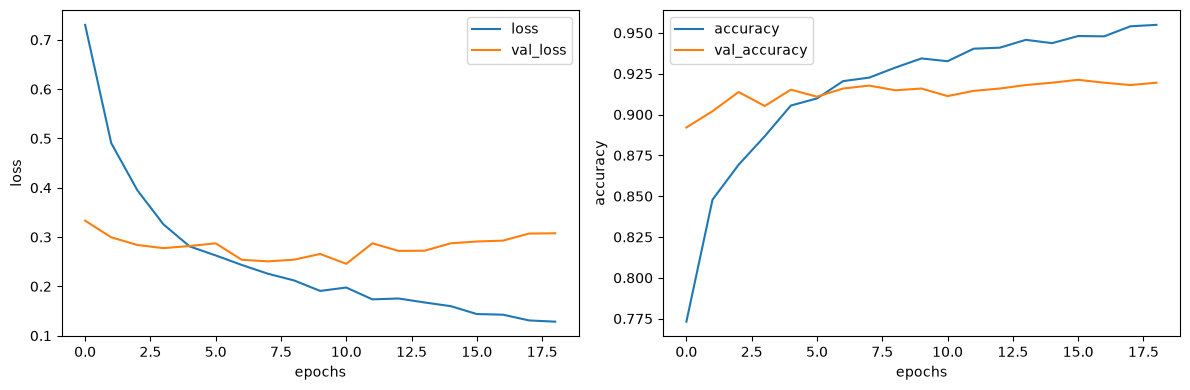

In [44]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")

plt.tight_layout()
plt.show()

Evaluación contra test, classification report y matriz de confusión del modelo de transfer learning:

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.9137 - loss: 0.2624
Test loss: 0.26236972212791443
Test accuracy: 0.9136666655540466
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step
              precision    recall  f1-score   support

   buildings       0.96      0.89      0.92       437
      forest       0.99      1.00      0.99       474
     glacier       0.86      0.84      0.85       553
    mountain       0.86      0.84      0.85       525
         sea       0.93      0.95      0.94       510
      street       0.92      0.97      0.94       501

    accuracy                           0.91      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.91      0.91      0.91      3000



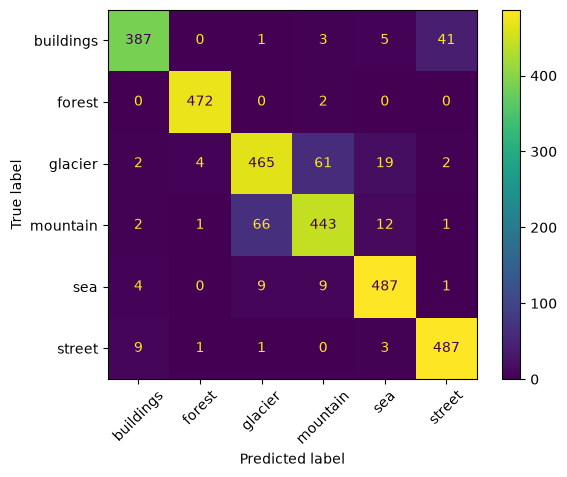

In [45]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=class_names, xticks_rotation=45)
plt.show()

### Ejercicio 4: Fine Tuning


In [46]:
print("Número de capas del modelo base:", len(base_model.layers))

FINE_TUNE_AT = len(base_model.layers) - 20

for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True

# MobileNetV2 tiene muchas capas BatchNormalization: si se descongelan, sus medias/varianzas
# se recalculan con los mini-batches del fine-tuning y desestabilizan las features ya aprendidas
# en imagenet (el sintoma tipico es que el fine-tuning empeora respecto al transfer learning).
# Por eso las mantenemos congeladas aunque esten dentro del rango de capas "descongelado".
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=Adam(learning_rate=1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Número de capas del modelo base: 154


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 3,741,318 (14.27 MB)

 Trainable params: 2,678,214 (10.22 MB)

 Non-trainable params: 1,063,104 (4.06 MB)

In [47]:
print("Número de capas del modelo base:", len(base_model.layers))

FINE_TUNE_AT = len(base_model.layers) - 20

for layer in base_model.layers[FINE_TUNE_AT:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Número de capas del modelo base: 154


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 3,741,318 (14.27 MB)

 Trainable params: 2,689,414 (10.26 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

In [48]:
early_stop_ft = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history_ft = model.fit(
    X_train, y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=30,
    callbacks=[early_stop_ft],
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.8349 - loss: 0.5864 - val_accuracy: 0.9131 - val_loss: 0.2785
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.8782 - loss: 0.3951 - val_accuracy: 0.9131 - val_loss: 0.2912
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.8852 - loss: 0.3558 - val_accuracy: 0.9141 - val_loss: 0.2760
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 104ms/step - accuracy: 0.9018 - loss: 0.2987 - val_accuracy: 0.9116 - val_loss: 0.2794
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.9097 - loss: 0.2724 - val_accuracy: 0.9116 - val_loss: 0.2787
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.9182 - loss: 0.2441 - val_accuracy: 0.9124 - val_loss: 0.2760
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 147ms/step - accuracy: 0.9226 - loss: 0.2340 - val_accuracy: 0.9099 - val_loss: 0.2831
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 144ms/step - accuracy: 0.9246 - loss: 0.22

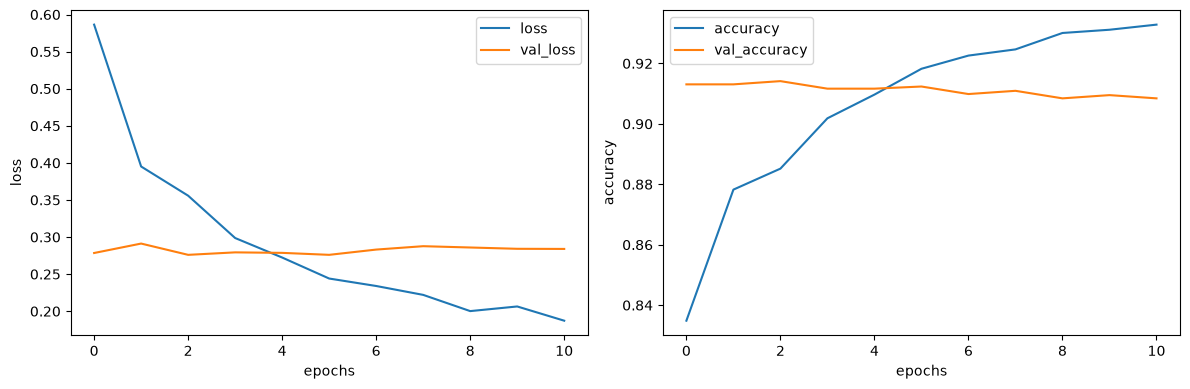

In [49]:
history_ft_df = pd.DataFrame(history_ft.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_ft_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")

history_ft_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")

plt.tight_layout()
plt.show()

Evaluación contra test, classification report y matriz de confusión tras el fine-tuning:

94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9093 - loss: 0.2869
Test loss (fine-tuning): 0.28685829043388367
Test accuracy (fine-tuning): 0.909333348274231
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step
              precision    recall  f1-score   support

   buildings       0.94      0.90      0.92       437
      forest       0.99      0.99      0.99       474
     glacier       0.85      0.85      0.85       553
    mountain       0.85      0.85      0.85       525
         sea       0.93      0.93      0.93       510
      street       0.92      0.95      0.94       501

    accuracy                           0.91      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.91      0.91      0.91      3000



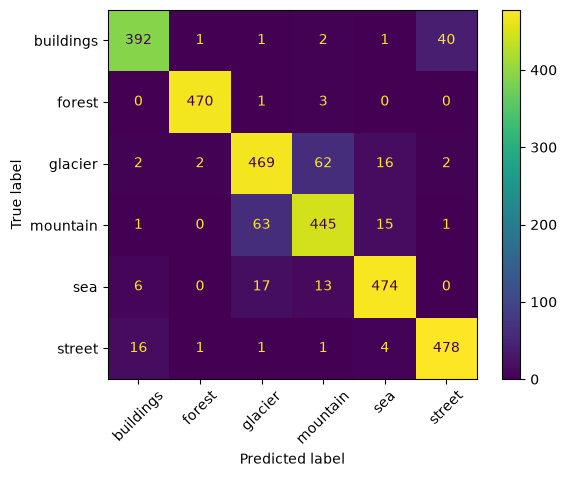

In [50]:
test_loss_ft, test_accuracy_ft = model.evaluate(X_test, y_test)
print("Test loss (fine-tuning):", test_loss_ft)
print("Test accuracy (fine-tuning):", test_accuracy_ft)

y_pred_probs_ft = model.predict(X_test)
y_pred_ft = np.argmax(y_pred_probs_ft, axis=1)

print(classification_report(y_test, y_pred_ft, target_names=class_names))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ft, display_labels=class_names, xticks_rotation=45)
plt.show()

### Ejercicio 5: Comparación de resultados

En la práctica obligatoria de la Unidad 1 la red convolucional ad-hoc (entrenada desde cero, sin pesos preentrenados) alcanzaba en test un accuracy en torno al 75%, con las confusiones más importantes entre glaciares y montañas (y en menor medida entre mar y montañas).

Comparando esos tres resultados —red ad-hoc (~75%), transfer learning (0.914) y fine-tuning (0.9093)— se espera que el transfer learning ya mejore a la red ad-hoc gracias a que las features convolucionales de MobileNetV2 vienen de haber visto millones de imágenes de imagenet (formas, texturas, bordes...), muy reutilizables para paisajes. El fine-tuning debería mejorar todavía un poco más al permitir que las últimas capas convolucionales, más específicas, se adapten al dominio concreto de los paisajes, aunque siendo que el datasets no es demasiado grande, la ganancia frente al transfer learning "puro" suele ser poca o incluso perder acurracy

### EXTRA: Transfer Learning con aumentado de imágenes

Repetimos el transfer learning (base congelada, misma cabeza) pero esta vez con un `ImageDataGenerator` que genera variaciones (rotación, desplazamiento, zoom, flip horizontal) de las imágenes de train en cada batch, para intentar mejorar la generalización.

In [51]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
)

train_generator = datagen.flow(X_tr, y_tr, batch_size=32)

In [52]:
base_model_aug = MobileNetV2(input_shape=INPUT_SHAPE, include_top=False, weights="imagenet")

for layer in base_model_aug.layers:
    layer.trainable = False

x = layers.Flatten()(base_model_aug.output)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
output_aug = layers.Dense(len(class_names), activation="softmax")(x)

model_aug = Model(base_model_aug.input, output_aug)
model_aug.compile(optimizer=Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

early_stop_aug = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

history_aug = model_aug.fit(
    train_generator,
    validation_data=(X_val, y_val),
    epochs=30,
    callbacks=[early_stop_aug],
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 49s 126ms/step - accuracy: 0.6968 - loss: 0.9203 - val_accuracy: 0.8846 - val_loss: 0.3573
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - accuracy: 0.7781 - loss: 0.6592 - val_accuracy: 0.8931 - val_loss: 0.3385
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.8052 - loss: 0.5975 - val_accuracy: 0.8921 - val_loss: 0.3437
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 133ms/step - accuracy: 0.8186 - loss: 0.5395 - val_accuracy: 0.8921 - val_loss: 0.3325
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 142ms/step - accuracy: 0.8330 - loss: 0.4852 - val_accuracy: 0.8953 - val_loss: 0.3391
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 137ms/step - accuracy: 0.8406 - loss: 0.4705 - val_accuracy: 0.8953 - val_loss: 0.3270
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.8441 - loss: 0.4600 - val_accuracy: 0.8963 - val_loss: 0.3235
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.8435 - loss: 0

KeyboardInterrupt: 

In [ ]:
history_aug_df = pd.DataFrame(history_aug.history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

history_aug_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("loss")

history_aug_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")

plt.tight_layout()
plt.show()

In [ ]:
test_loss_aug, test_accuracy_aug = model_aug.evaluate(X_test, y_test)
print("Test loss (aug):", test_loss_aug)
print("Test accuracy (aug):", test_accuracy_aug)

y_pred_probs_aug = model_aug.predict(X_test)
y_pred_aug = np.argmax(y_pred_probs_aug, axis=1)

print(classification_report(y_test, y_pred_aug, target_names=class_names))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_aug, display_labels=class_names, xticks_rotation=45)
plt.show()

*(Completa esta conclusión con `test_accuracy_aug` una vez ejecutado)*: el aumentado de imágenes suele ayudar sobre todo cuando el dataset de train es pequeño o el modelo tiende a sobreajustar; con ~14.000 imágenes de train como en este dataset el efecto puede ser modesto, pero normalmente se traduce en una `val_loss`/`val_accuracy` algo más estable (menos gap entre train y validación) aunque el entrenamiento tarde más en converger al ser un problema algo más difícil en cada batch.